In [2]:
# 1-21

# Suppose a coin has porbability p of landing heads. Take p = 0.3, n = 1_000. Simulate n coin flips.
# Graph the proportion of heads as a function of n.
# Repeat for p = 0.03

In [3]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

seed = 42

%matplotlib inline

np.set_printoptions(precision=4, suppress=True)

In [4]:
# Take p = 0.3, n = 1_000. Simulate n coin flips.

# 1. Enforce reproducibility (Industry Standard)
# Using the modern NumPy random Generator API rather than np.random.seed()
rng = np.random.default_rng(seed)

# 2. Define simulation parameters
n_flips = 1_000
p_heads = 0.3  # Biased probability of success (Heads/Default/Signal hit)

# 3. Generate the sample space empirically via a vectorized operation
# A standard uniform distribution U(0, 1) cut at p gives exactly probability p
uniform_shocks = rng.random(size=n_flips)
coin_flips = (uniform_shocks < p_heads).astype(int)

# 4. Pack into a Pandas Series for easy analysis and structural alignment
simulation_series = pd.Series(coin_flips, name="Coin_Flips")

# 5. Verify the frequentist properties (Wasserman Chapter 1)
empirical_p = simulation_series.mean()
total_heads = simulation_series.sum()

print(f"Total Heads (Successes): {total_heads} out of {n_flips}")
print(f"Empirical Probability: {empirical_p:.4f} (Target: {p_heads})")


Total Heads (Successes): 308 out of 1000
Empirical Probability: 0.3080 (Target: 0.3)


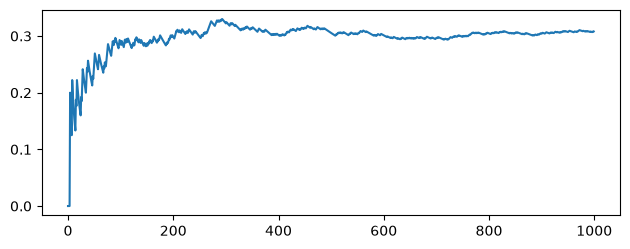

In [5]:
# Graph the proportion of heads as a function of n

# 1. Enforce reproducibility using the modern NumPy Generator API
rng = np.random.default_rng(seed)

# 2. Define simulation parameters
n_flips = 1_000
p_heads = 0.3

# 3. Vectorized simulation of Bernoulli trials
uniform_shocks = rng.random(size=n_flips)
coin_flips = (uniform_shocks < p_heads).astype(int)

# 4. Generate running metrics using NumPy vectorized accumulations
n_axis = np.arange(1, n_flips + 1)
cumulative_heads = np.cumsum(coin_flips)
cumulative_proportion = cumulative_heads / n_axis

# 5. Plotting directly using subplots (avoiding plt.figure() per guidelines)
# Top Subplot: Convergence of Proportion (Relative Frequency)
plt.subplot(2, 1, 1)
plt.plot(
    # n_axis,
    cumulative_proportion,
    # label="Empirical Proportion",
    # color="#1f77b4",
    # linewidth=1.5,
)
# plt.axhline(y=p_heads, color="red", linestyle="--", label=f"True $p = {p_heads}$")
# plt.title("Wasserman Ch. 1: Convergence of Empirical Probability")
# plt.ylabel("Proportion of Heads")
# plt.grid(True, linestyle=":", alpha=0.6)
# plt.legend()

# Bottom Subplot: Cumulative Count of Successes
# plt.subplot(2, 1, 2)
# plt.plot(
#     n_axis, cumulative_heads, label="Cumulative Heads", color="#2ca02c", linewidth=1.5
# )
# plt.plot(
#     n_axis,
#     n_axis * p_heads,
#     color="red",
#     linestyle="--",
#     label=f"Expected ($n \\times {p_heads}$)",
# )
# plt.title("Absolute Cumulative Count of Successes")
# plt.xlabel("Number of Trials ($n$)")
# plt.ylabel("Total Heads")
# plt.grid(True, linestyle=":", alpha=0.6)
# plt.legend()

# 6. Final layout formatting and production export
plt.tight_layout()
plt.savefig("coin_flips_simulation.png", dpi=300)


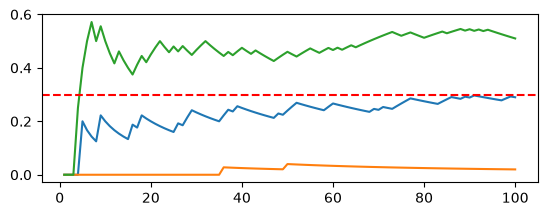

In [6]:
# 1. Enforce reproducibility using the modern NumPy Generator API
rng = np.random.default_rng(seed)

# 2. Define simulation parameters
n_flips = 100
p_heads_original = 0.3
p_heads_low = 0.03
p_heads_fair = 0.5


# 3. Vectorized simulation of Bernoulli trials
def simulate_coin_flips(p_heads, n_flips, rng):
    uniform_shocks = rng.random(size=n_flips)
    return (uniform_shocks < p_heads).astype(int)


# 4. Generate running metrics using NumPy vectorized accumulations
def compute_cumulative_proportion(coin_flips):
    n_axis = np.arange(1, len(coin_flips) + 1)
    cumulative_heads = np.cumsum(coin_flips)
    return n_axis, cumulative_heads / n_axis


# 5. Plotting directly using subplots (avoiding plt.figure() per guidelines)
plt.subplot(2, 1, 1)
for p_heads, label in zip(
    [p_heads_original, p_heads_low, p_heads_fair],
    ["Biased (p=0.3)", "Highly Biased (p=0.03)", "Fair Coin (p=0.5)"],
):
    coin_flips = simulate_coin_flips(p_heads, n_flips, rng)
    n_axis, cumulative_proportion = compute_cumulative_proportion(coin_flips)
    plt.plot(
        n_axis,
        cumulative_proportion,
        label=label,
        linewidth=1.5,
    )

plt.axhline(
    y=p_heads_original,
    color="red",
    linestyle="--",
    label=f"True $p = {p_heads_original}$",
)
# plt.title("Wasserman Ch. 1: Convergence of Empirical Probability")
# plt.ylabel("Proportion of Heads")
# plt.grid(True, linestyle=":", alpha=0.6)
# plt.legend()
# plt.xlabel("Number of Flips")
# plt.tight_layout()


Generator(PCG64)
Uniform Shocks Sample: [0.774  0.4389 0.8586 0.6974 0.0942], shape: (1000,)

Simulating for Biased (p=0.3) with p=0.3: Total Heads = 308
n_axis Sample: [1 2 3 4 5]
Proportion for Biased (p=0.3): [0.     0.     0.     0.     0.2    0.1667 0.1429 0.125  0.2222 0.2
 0.1818 0.1667 0.1538 0.1429 0.1333 0.1875 0.1765 0.2222 0.2105 0.2
 0.1905 0.1818 0.1739 0.1667 0.16   0.1923 0.1852 0.2143 0.2414 0.2333
 0.2258 0.2188 0.2121 0.2059 0.2    0.2222 0.2432 0.2368 0.2564 0.25
 0.2439 0.2381 0.2326 0.2273 0.2222 0.2174 0.2128 0.2292 0.2245 0.24
 0.2549 0.2692 0.2642 0.2593 0.2545 0.25   0.2456 0.2414 0.2542 0.2667
 0.2623 0.2581 0.254  0.25   0.2462 0.2424 0.2388 0.2353 0.2464 0.2429
 0.2535 0.25   0.2466 0.2568 0.2667 0.2763 0.2857 0.2821 0.2785 0.275
 0.2716 0.2683 0.2651 0.2738 0.2824 0.2907 0.2874 0.2841 0.2921 0.2889
 0.2967 0.2935 0.2903 0.2872 0.2842 0.2812 0.2784 0.2857 0.2929 0.29
 0.2871 0.2843 0.2913 0.2885 0.2857 0.283  0.2804 0.287  0.2936 0.2909
 0.2883 0.2946 0.292

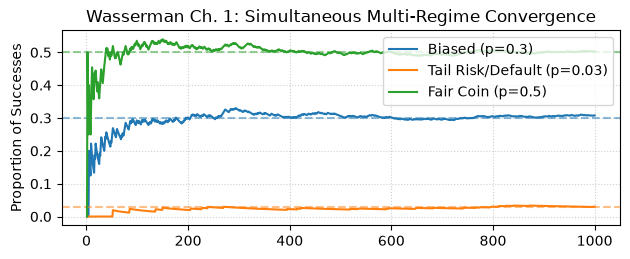

In [7]:
# Generate a single matrix of underlying random shocks first, ensuring that all three coins face the exact same market conditions simultaneously (Simultaneous Multi-Asset Simulation).

# 1. Enforce reproducibility using the modern NumPy Generator API
rng = np.random.default_rng(seed)
print(rng)

# 2. Define simulation parameters - Keeping n higher for LLN convergence
n_flips = 1_000
probabilities = [0.3, 0.03, 0.5]
labels = ["Biased (p=0.3)", "Tail Risk/Default (p=0.03)", "Fair Coin (p=0.5)"]
colors = ["#1f77b4", "#ff7f0e", "#2ca02c"]

# 3. ADVANCED QUANT PRACTICE: Generate a single unified matrix of shocks
# This ensures all assets experience the exact same historical timeline/paths
uniform_shocks = rng.random(size=n_flips)
print(
    f"Uniform Shocks Sample: {uniform_shocks[:5]}, shape: {uniform_shocks.shape}"
)  # Debugging output to verify shock generation
print()  # Blank line for readability

# 4. Plotting directly using subplots (No loops or explicit plt.figure)
plt.subplot(2, 1, 1)

for p, label, color in zip(probabilities, labels, colors):
    # Broadcast the single shock matrix against each unique probability threshold
    coin_flips = (uniform_shocks < p).astype(int)
    print(f"Simulating for {label} with p={p}: Total Heads = {coin_flips.sum()}")

    # Compute vectorized metrics
    n_axis = np.arange(1, n_flips + 1)
    print(
        f"n_axis Sample: {n_axis[:5]}"
    )  # Debugging output to verify n_axis generation
    cumulative_proportion = np.cumsum(coin_flips) / n_axis
    print(f"Proportion for {label}: {cumulative_proportion[:200]} (Target: {p})")
    print()  # Blank line for readability

    # Plot empirical convergence line
    plt.plot(n_axis, cumulative_proportion, label=label, color=color, linewidth=1.5)

    # Plot corresponding true probability baseline
    plt.axhline(y=p, color=color, linestyle="--", alpha=0.5)

# Formatting according to professional notebook standards
plt.title("Wasserman Ch. 1: Simultaneous Multi-Regime Convergence")
plt.ylabel("Proportion of Successes")
plt.grid(True, linestyle=":", alpha=0.6)
plt.legend(loc="upper right")

plt.tight_layout()
plt.show()

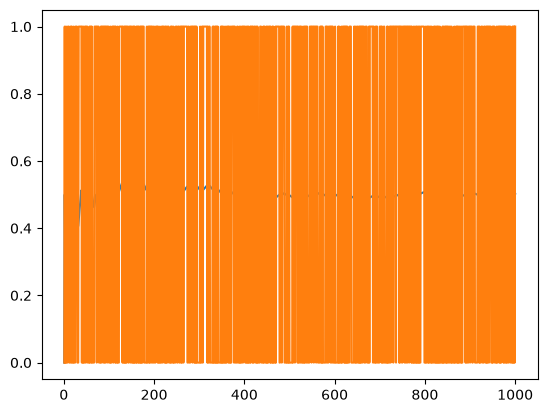

In [8]:
plt.plot(n_axis, cumulative_proportion)
plt.plot(n_axis, coin_flips)